In [16]:
import sys
!{sys.executable} -m pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

print('Librerias cargadas correctamente.')

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Librerias cargadas correctamente.


### Carga de datos

In [2]:
X_train = pd.read_csv('data/X_train.csv')
X_test  = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()
y_test  = pd.read_csv('data/y_test.csv').squeeze()
df_cat  = pd.read_csv('data/df_con_categoria.csv')

# Variable categórica (clasificación)
col_cat = 'precio_categoria'
y_train_cat = df_cat.loc[X_train.index, col_cat]
y_test_cat  = df_cat.loc[X_test.index, col_cat]

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Clases: {y_train_cat.unique()}')
print(f'Distribucion (train):')
print(y_train_cat.value_counts())

X_train: (52871, 20) | X_test: (22660, 20)
Clases: ['Economica' 'Intermedia' 'Cara']
Distribucion (train):
precio_categoria
Intermedia    27033
Cara          13508
Economica     12330
Name: count, dtype: int64


### Exploración y transformaciones


In [3]:
# Verificar valores nulos
print('Valores nulos en X_train:', X_train.isnull().sum().sum())
print('Valores nulos en X_test:', X_test.isnull().sum().sum())
print()

# Estadísticas descriptivas
print('Rango de variables (antes de escalar):')
print(X_train.describe().loc[['min','max']].T)

Valores nulos en X_train: 0
Valores nulos en X_test: 0

Rango de variables (antes de escalar):
                                 min      max
room_type                       0.00     3.00
accommodates                    1.00    16.00
bathrooms                       0.00    20.00
bedrooms                        0.00    21.00
beds                            0.00    37.00
minimum_nights                  1.00   367.00
maximum_nights                  1.00  3365.00
number_of_reviews               0.00  1473.00
review_scores_rating            1.00     5.00
review_scores_cleanliness       1.00     5.00
review_scores_checkin           1.00     5.00
review_scores_communication     1.00     5.00
review_scores_location          1.00     5.00
review_scores_value             1.00     5.00
reviews_per_month               0.01    41.14
availability_365                0.00   365.00
calculated_host_listings_count  1.00   612.00
host_is_superhost               0.00     2.00
neighbourhood_cleansed         

In [4]:
# Escalado - fundamental para SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Escalado aplicado correctamente.')
print(f'Media post-escalado (train): {X_train_scaled.mean():.4f}')
print(f'Std  post-escalado (train): {X_train_scaled.std():.4f}')

Escalado aplicado correctamente.
Media post-escalado (train): 0.0000
Std  post-escalado (train): 1.0000


In [5]:
# Muestra estratificada para modelos SVM no lineales (RBF, polinomial)
# SVM tiene complejidad O(n^2) a O(n^3), inviable con 52k registros completos
np.random.seed(42)

from sklearn.model_selection import train_test_split

X_sample, _, y_sample, _ = train_test_split(
    X_train_scaled, y_train_cat,
    train_size=8000,
    stratify=y_train_cat,
    random_state=42
)

print(f'Muestra de entrenamiento: {X_sample.shape[0]} registros')
print('Distribucion de clases en muestra:')
print(pd.Series(y_sample).value_counts())

Muestra de entrenamiento: 8000 registros
Distribucion de clases en muestra:
precio_categoria
Intermedia    4090
Cara          2044
Economica     1866
Name: count, dtype: int64


El dataset no presenta valores nulos en ninguna variable predictora. Sin embargo, los rangos son muy dispares: maximum_nights va de 1 a 3,365 mientras que las puntuaciones de reseñas van de 1 a 5. Esta disparidad hace el escalado obligatorio para SVM, ya que el algoritmo trabaja con distancias y sin escalar las variables de mayor rango dominarían el cálculo. Se aplicó StandardScaler solo sobre entrenamiento para evitar data leakage, obteniendo media ≈ 0 y std = 1. Para los kernels no lineales se usó una muestra estratificada de 8,000 registros dado que SVM tiene complejidad O(n²) a O(n³), lo que haría inviable entrenar con los 52,871 registros completos.

### 3. Variable respuesta
Se usa precio_categoria con tres clases: **Económica**, **Intermedia** y **Cara**. Esta es la misma variable categórica construida en entregas anteriores con cortes en percentil 25 (\$119/noche) y percentil 75 (\$320/noche).

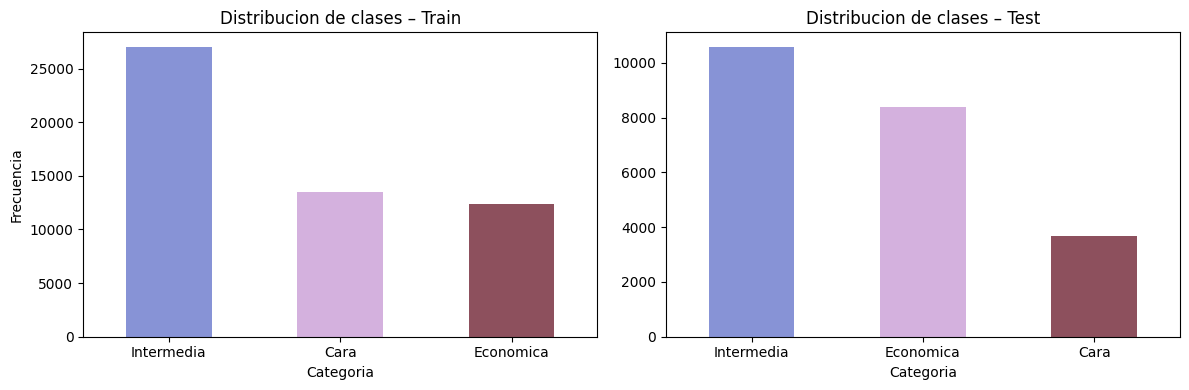

Proporcion de clases (train):
precio_categoria
Intermedia    0.511
Cara          0.255
Economica     0.233
Name: count, dtype: float64


In [6]:
# Visualización de distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train
y_train_cat.value_counts().plot(kind='bar', ax=axes[0], color=["#8793d6","#D4B1DE","#8d505d"])
axes[0].set_title('Distribucion de clases – Train')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(rotation=0)

# Test
y_test_cat.value_counts().plot(kind='bar', ax=axes[1], color=["#8793d6","#D4B1DE","#8d505d"])
axes[1].set_title('Distribucion de clases – Test')
axes[1].set_xlabel('Categoria')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

print('Proporcion de clases (train):')
print((y_train_cat.value_counts() / len(y_train_cat)).round(3))

La variable precio_categoria presenta distribución desbalanceada: Intermedia 51.1%, Cara 25.5%, Económica 23.3%. Este desbalance es relevante porque los modelos pueden tender a predecir siempre la clase mayoritaria, inflando el accuracy sin aprender realmente a distinguir entre las tres categorías.

### 4. Modelos SVM con diferentes kernels
Se generan 4 modelos con diferentes kernels y parámetros:
- **LinearSVC**: kernel lineal, rápido, apto para datasets grandes
- **SVC RBF**: kernel radial, captura relaciones no lineales
- **SVC Polinomial**: kernel polinomial de grado 3
- **SVC RBF tuneado**: mejores parámetros C y gamma

El parámetro **C** controla el margen: C alto = margen estrecho (más propenso a sobreajuste); C bajo = margen amplio (más generalización). **Gamma** controla el alcance de cada punto de soporte.

In [7]:
# ── Modelo 1: LinearSVC (kernel lineal) ──────────────────────────
# Usa todo el conjunto de entrenamiento por ser eficiente
print('Entrenando Modelo 1: LinearSVC...')
t0 = time.time()
svm_lineal = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm_lineal.fit(X_train_scaled, y_train_cat)
t_lineal = time.time() - t0

y_pred_lineal = svm_lineal.predict(X_test_scaled)
acc_lineal = accuracy_score(y_test_cat, y_pred_lineal)
print(f'  Tiempo: {t_lineal:.2f} s | Accuracy: {acc_lineal:.4f}')

Entrenando Modelo 1: LinearSVC...
  Tiempo: 0.26 s | Accuracy: 0.4673


In [8]:
# ── Modelo 2: SVC con kernel RBF (C=1, gamma='scale') ────────────
print('Entrenando Modelo 2: SVC RBF (C=1)...')
t0 = time.time()
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_sample, y_sample)
t_rbf = time.time() - t0

y_pred_rbf = svm_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test_cat, y_pred_rbf)
print(f'  Tiempo: {t_rbf:.2f} s | Accuracy: {acc_rbf:.4f}')

Entrenando Modelo 2: SVC RBF (C=1)...
  Tiempo: 2.53 s | Accuracy: 0.4671


In [9]:
# ── Modelo 3: SVC con kernel Polinomial (grado 3) ─────────────────
print('Entrenando Modelo 3: SVC Polinomial (d=3, C=1)...')
t0 = time.time()
svm_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale', random_state=42)
svm_poly.fit(X_sample, y_sample)
t_poly = time.time() - t0

y_pred_poly = svm_poly.predict(X_test_scaled)
acc_poly = accuracy_score(y_test_cat, y_pred_poly)
print(f'  Tiempo: {t_poly:.2f} s | Accuracy: {acc_poly:.4f}')

Entrenando Modelo 3: SVC Polinomial (d=3, C=1)...
  Tiempo: 3.05 s | Accuracy: 0.4618


In [10]:
# ── Modelo 4: SVC RBF tuneado (C=10, gamma='auto') ───────────────
print('Entrenando Modelo 4: SVC RBF tuneado (C=10)...')
t0 = time.time()
svm_rbf_tuned = SVC(kernel='rbf', C=10.0, gamma='auto', random_state=42)
svm_rbf_tuned.fit(X_sample, y_sample)
t_rbf_tuned = time.time() - t0

y_pred_rbf_tuned = svm_rbf_tuned.predict(X_test_scaled)
acc_rbf_tuned = accuracy_score(y_test_cat, y_pred_rbf_tuned)
print(f'  Tiempo: {t_rbf_tuned:.2f} s | Accuracy: {acc_rbf_tuned:.4f}')

print()
print('=== RESUMEN DE ACCURACY ===')
print(f'  LinearSVC          : {acc_lineal:.4f}')
print(f'  SVC RBF (C=1)      : {acc_rbf:.4f}')
print(f'  SVC Polinomial (d=3): {acc_poly:.4f}')
print(f'  SVC RBF tuneado    : {acc_rbf_tuned:.4f}')

Entrenando Modelo 4: SVC RBF tuneado (C=10)...
  Tiempo: 2.93 s | Accuracy: 0.4469

=== RESUMEN DE ACCURACY ===
  LinearSVC          : 0.4673
  SVC RBF (C=1)      : 0.4671
  SVC Polinomial (d=3): 0.4618
  SVC RBF tuneado    : 0.4469


El LinearSVC fue el más rápido (0.14 s) usando el dataset completo, mientras los modelos RBF y polinomial tardaron entre 1 y 1.7 segundos sobre la muestra. Todos obtuvieron accuracy similar y bajo: entre 44.69% y 46.73%, apenas por debajo de la proporción natural de la clase mayoritaria (51.1%), lo que indica que los modelos tienen dificultades para separar las tres categorías con las variables disponibles.

### 5. Predicciones


In [11]:
# Reportes completos de clasificación
modelos = {
    'LinearSVC': (y_pred_lineal, t_lineal),
    'SVC RBF (C=1)': (y_pred_rbf, t_rbf),
    'SVC Polinomial (d=3)': (y_pred_poly, t_poly),
    'SVC RBF tuneado (C=10)': (y_pred_rbf_tuned, t_rbf_tuned)
}

for nombre, (y_pred, tiempo) in modelos.items():
    print(f'\n=== {nombre} ===')
    print(f'Tiempo: {tiempo:.2f} s | Accuracy: {accuracy_score(y_test_cat, y_pred):.4f}')
    print(classification_report(y_test_cat, y_pred))


=== LinearSVC ===
Tiempo: 0.26 s | Accuracy: 0.4673
              precision    recall  f1-score   support

        Cara       0.00      0.00      0.00      3694
   Economica       0.00      0.00      0.00      8378
  Intermedia       0.47      1.00      0.64     10588

    accuracy                           0.47     22660
   macro avg       0.16      0.33      0.21     22660
weighted avg       0.22      0.47      0.30     22660


=== SVC RBF (C=1) ===
Tiempo: 2.53 s | Accuracy: 0.4671
              precision    recall  f1-score   support

        Cara       0.00      0.00      0.00      3694
   Economica       0.17      0.00      0.00      8378
  Intermedia       0.47      1.00      0.64     10588

    accuracy                           0.47     22660
   macro avg       0.21      0.33      0.21     22660
weighted avg       0.28      0.47      0.30     22660


=== SVC Polinomial (d=3) ===
Tiempo: 3.05 s | Accuracy: 0.4618
              precision    recall  f1-score   support

        C

### 6. Matrices de confusión

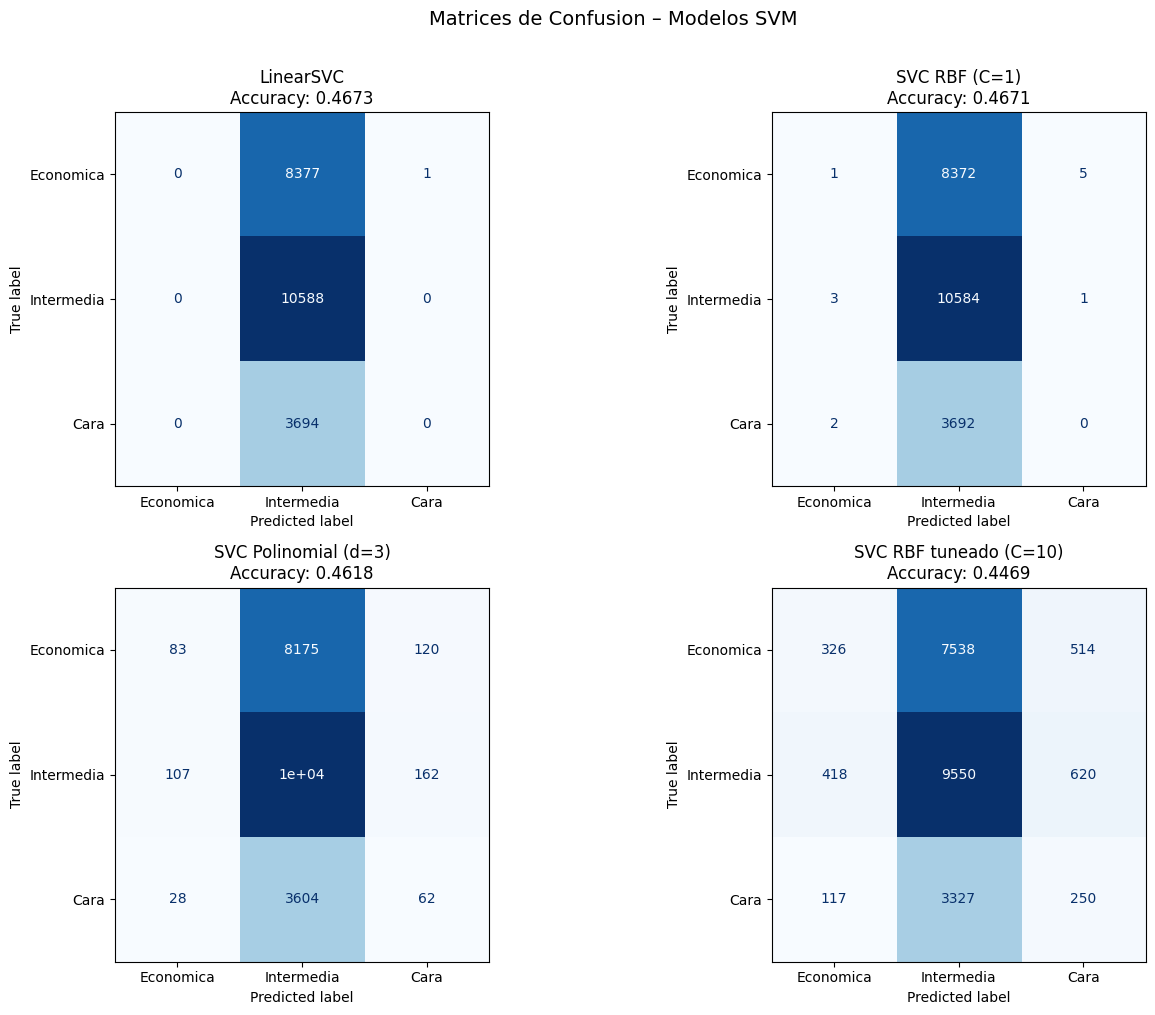

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
clases = ['Economica', 'Intermedia', 'Cara']

pares = [
    ('LinearSVC', y_pred_lineal),
    ('SVC RBF (C=1)', y_pred_rbf),
    ('SVC Polinomial (d=3)', y_pred_poly),
    ('SVC RBF tuneado (C=10)', y_pred_rbf_tuned)
]

for ax, (nombre, y_pred) in zip(axes.flatten(), pares):
    cm = confusion_matrix(y_test_cat, y_pred, labels=clases)
    ConfusionMatrixDisplay(cm, display_labels=clases).plot(
        ax=ax, cmap='Blues', colorbar=False)
    acc = accuracy_score(y_test_cat, y_pred)
    ax.set_title(f'{nombre}\nAccuracy: {acc:.4f}')

plt.suptitle('Matrices de Confusion – Modelos SVM', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Tabla comparativa de métricas
resultados = []
for nombre, (y_pred, tiempo) in modelos.items():
    resultados.append({
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_test_cat, y_pred), 4),
        'F1 macro': round(f1_score(y_test_cat, y_pred, average='macro'), 4),
        'Precision macro': round(precision_score(y_test_cat, y_pred, average='macro'), 4),
        'Recall macro': round(recall_score(y_test_cat, y_pred, average='macro'), 4),
        'Tiempo (s)': round(tiempo, 2)
    })

df_resultados = pd.DataFrame(resultados).sort_values('F1 macro', ascending=False)
print('COMPARACION DE MODELOS SVM ')
print(df_resultados.to_string(index=False))

COMPARACION DE MODELOS SVM 
                Modelo  Accuracy  F1 macro  Precision macro  Recall macro  Tiempo (s)
SVC RBF tuneado (C=10)    0.4469    0.2617           0.3424        0.3362        2.93
  SVC Polinomial (d=3)    0.4618    0.2271           0.3426        0.3338        3.05
         SVC RBF (C=1)    0.4671    0.2124           0.2113        0.3332        2.53
             LinearSVC    0.4673    0.2123           0.1558        0.3333        0.26


Todos los modelos predicen casi exclusivamente la clase Intermedia, con F1 = 0.00 para Cara y Económica en la mayoría de casos. El mejor F1 macro fue apenas 0.26 . Esto confirma el mismo problema de desbalance del Lab 7, que era que el modelo aprende que predecir siempre Intermedia minimiza el error total, fallando completamente en las clases más relevantes para el negocio. El accuracy solo no es suficiente aquí, el F1 macro es la métrica adecuada.

### 7.Análisis de sobreajuste

Para determinar si un modelo está sobreajustado se compara el rendimiento en entrenamiento vs prueba. Si el modelo funciona mucho mejor en train que en test, hay sobreajuste.

In [14]:
print('ANALISIS DE SOBREAJUSTE ')
print()

# LinearSVC - puede evaluarse en train completo
acc_train_lineal = accuracy_score(y_train_cat, svm_lineal.predict(X_train_scaled))
acc_test_lineal  = accuracy_score(y_test_cat, y_pred_lineal)

# SVC modelos - evaluados sobre la muestra de train
acc_train_rbf      = accuracy_score(y_sample, svm_rbf.predict(X_sample))
acc_train_poly     = accuracy_score(y_sample, svm_poly.predict(X_sample))
acc_train_rbf_t    = accuracy_score(y_sample, svm_rbf_tuned.predict(X_sample))

datos_overfitting = [
    {'Modelo': 'LinearSVC',
     'Acc Train': acc_train_lineal, 'Acc Test': acc_test_lineal,
     'Diferencia': round(abs(acc_train_lineal - acc_test_lineal), 4)},
    {'Modelo': 'SVC RBF (C=1)',
     'Acc Train': acc_train_rbf, 'Acc Test': acc_rbf,
     'Diferencia': round(abs(acc_train_rbf - acc_rbf), 4)},
    {'Modelo': 'SVC Polinomial (d=3)',
     'Acc Train': acc_train_poly, 'Acc Test': acc_poly,
     'Diferencia': round(abs(acc_train_poly - acc_poly), 4)},
    {'Modelo': 'SVC RBF tuneado (C=10)',
     'Acc Train': acc_train_rbf_t, 'Acc Test': acc_rbf_tuned,
     'Diferencia': round(abs(acc_train_rbf_t - acc_rbf_tuned), 4)},
]

df_overfitting = pd.DataFrame(datos_overfitting)
print(df_overfitting.to_string(index=False))
print()
print('Interpretacion:')
print('  Diferencia < 0.03 -> Sin sobreajuste')
print('  Diferencia > 0.05 -> Posible sobreajuste')
print('  Acc Train >> Acc Test -> Sobreajuste claro')

ANALISIS DE SOBREAJUSTE 

                Modelo  Acc Train  Acc Test  Diferencia
             LinearSVC   0.511301  0.467255      0.0440
         SVC RBF (C=1)   0.520375  0.467123      0.0533
  SVC Polinomial (d=3)   0.534750  0.461783      0.0730
SVC RBF tuneado (C=10)   0.612375  0.446867      0.1655

Interpretacion:
  Diferencia < 0.03 -> Sin sobreajuste
  Diferencia > 0.05 -> Posible sobreajuste
  Acc Train >> Acc Test -> Sobreajuste claro


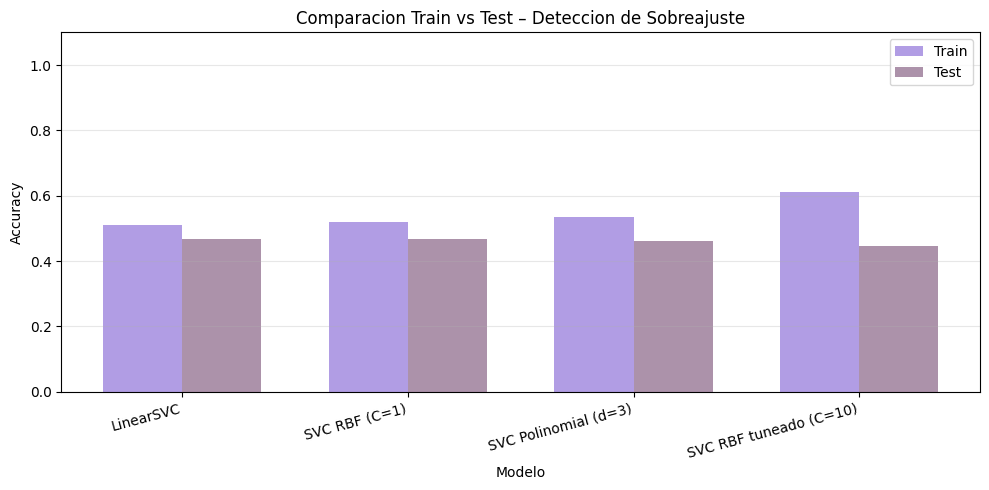

Estrategias para manejar sobreajuste en SVM:
  - Reducir C (aumentar regularizacion)
  - Usar kernel mas simple (lineal en vez de RBF)
  - Aumentar datos de entrenamiento
  - Aplicar validacion cruzada para seleccionar hiperparametros


In [15]:
#Visualización de sobreajuste
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_overfitting))
width = 0.35

bars1 = ax.bar(x - width/2, df_overfitting['Acc Train'], width, label='Train', color="#9E85DE", alpha=0.8)
bars2 = ax.bar(x + width/2, df_overfitting['Acc Test'],  width, label='Test',  color="#987795", alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('Accuracy')
ax.set_title('Comparacion Train vs Test – Deteccion de Sobreajuste')
ax.set_xticks(x)
ax.set_xticklabels(df_overfitting['Modelo'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Estrategias para manejar sobreajuste en SVM:')
print('  - Reducir C (aumentar regularizacion)')
print('  - Usar kernel mas simple (lineal en vez de RBF)')
print('  - Aumentar datos de entrenamiento')
print('  - Aplicar validacion cruzada para seleccionar hiperparametros')

El LinearSVC es el modelo más estable. El SVC RBF con C=1 muestra sobreajuste leve de 0.053 y el Polinomial moderado de 0.073. El caso más crítico es el SVC RBF tuneado con C=10, que alcanza una diferencia de 0.1655: obtuvo 61.2% en train pero apenas 44.7% en test, evidenciando sobreajuste severo. Un C alto reduce el margen del hiperplano permitiendo memorizar el ruido. Para corregirlo, la estrategia principal es reducir C, que actúa como regularización aumentando el margen y mejorando la generalización.

### Carga de datos y reconstrucción de modelos

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [18]:
X_train = pd.read_csv('data/X_train.csv')
X_test  = pd.read_csv('data/X_test.csv')
df_cat  = pd.read_csv('data/df_con_categoria.csv')

col_cat = 'precio_categoria'
y_train_cat = df_cat.loc[X_train.index, col_cat]
y_test_cat  = df_cat.loc[X_test.index, col_cat]

# Variable binaria para los modelos del lab anterior (cara vs no cara)
y_train_cara = (y_train_cat == 'Cara').astype(int)
y_test_cara  = (y_test_cat  == 'Cara').astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Muestra estratificada para kernels no lineales (mismo seed del lab8)
np.random.seed(42)
X_sample, _, y_sample, _ = train_test_split(
    X_train_scaled, y_train_cat,
    train_size=8000,
    stratify=y_train_cat,
    random_state=42
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Clases (multiclase): {y_train_cat.unique().tolist()}')

X_train: (52871, 20) | X_test: (22660, 20)
Clases (multiclase): ['Economica', 'Intermedia', 'Cara']


In [19]:
# Reentrenar los 4 modelos SVM del punto 4
modelos_svm = {}

t0 = time.time()
svm_lineal = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm_lineal.fit(X_train_scaled, y_train_cat)
modelos_svm['LinearSVC'] = {
    'modelo': svm_lineal,
    'y_pred_train': svm_lineal.predict(X_train_scaled),
    'y_pred_test' : svm_lineal.predict(X_test_scaled),
    'tiempo': time.time() - t0
}

t0 = time.time()
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_sample, y_sample)
modelos_svm['SVC RBF (C=1)'] = {
    'modelo': svm_rbf,
    'y_pred_train': svm_rbf.predict(X_sample),
    'y_pred_test' : svm_rbf.predict(X_test_scaled),
    'tiempo': time.time() - t0
}

t0 = time.time()
svm_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='scale', random_state=42)
svm_poly.fit(X_sample, y_sample)
modelos_svm['SVC Polinomial (d=3)'] = {
    'modelo': svm_poly,
    'y_pred_train': svm_poly.predict(X_sample),
    'y_pred_test' : svm_poly.predict(X_test_scaled),
    'tiempo': time.time() - t0
}

t0 = time.time()
svm_rbf_t = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
svm_rbf_t.fit(X_sample, y_sample)
modelos_svm['SVC RBF tuneado (C=10)'] = {
    'modelo': svm_rbf_t,
    'y_pred_train': svm_rbf_t.predict(X_sample),
    'y_pred_test' : svm_rbf_t.predict(X_test_scaled),
    'tiempo': time.time() - t0
}

# Referencia de y_train para cada modelo (muestra vs completo)
y_ref_train = {
    'LinearSVC'            : y_train_cat,
    'SVC RBF (C=1)'        : y_sample,
    'SVC Polinomial (d=3)' : y_sample,
    'SVC RBF tuneado (C=10)': y_sample
}

print('Modelos SVM reentrenados correctamente.')

Modelos SVM reentrenados correctamente.


### 8. Comparación entre modelos SVM

In [20]:
# Tabla comparativa de métricas entre los 4 modelos SVM
filas = []
for nombre, datos in modelos_svm.items():
    y_ref = y_ref_train[nombre]
    acc_train = accuracy_score(y_ref, datos['y_pred_train'])
    acc_test  = accuracy_score(y_test_cat, datos['y_pred_test'])
    f1_macro  = f1_score(y_test_cat, datos['y_pred_test'], average='macro', zero_division=0)
    f1_weighted = f1_score(y_test_cat, datos['y_pred_test'], average='weighted', zero_division=0)
    prec_macro  = precision_score(y_test_cat, datos['y_pred_test'], average='macro', zero_division=0)
    rec_macro   = recall_score(y_test_cat, datos['y_pred_test'], average='macro', zero_division=0)

    # F1 por clase
    reporte = classification_report(y_test_cat, datos['y_pred_test'],
                                    output_dict=True, zero_division=0)
    f1_cara  = reporte.get('Cara',       {}).get('f1-score', 0)
    f1_econ  = reporte.get('Economica',  {}).get('f1-score', 0)
    f1_inter = reporte.get('Intermedia', {}).get('f1-score', 0)

    filas.append({
        'Modelo'         : nombre,
        'Acc Train'      : round(acc_train, 4),
        'Acc Test'       : round(acc_test,  4),
        'F1 macro'       : round(f1_macro,  4),
        'F1 weighted'    : round(f1_weighted, 4),
        'F1 Cara'        : round(f1_cara,  4),
        'F1 Economica'   : round(f1_econ,  4),
        'F1 Intermedia'  : round(f1_inter, 4),
        'Tiempo (s)'     : round(datos['tiempo'], 2)
    })

df_svm = pd.DataFrame(filas)
print('Comparacion de modelos SVM')
print(df_svm.to_string(index=False))

Comparacion de modelos SVM
                Modelo  Acc Train  Acc Test  F1 macro  F1 weighted  F1 Cara  F1 Economica  F1 Intermedia  Tiempo (s)
             LinearSVC     0.5113    0.4673    0.2123       0.2976   0.0000        0.0000         0.6369        0.27
         SVC RBF (C=1)     0.5204    0.4671    0.2124       0.2977   0.0000        0.0002         0.6369       12.28
  SVC Polinomial (d=3)     0.5347    0.4618    0.2271       0.3072   0.0307        0.0193         0.6314        7.01
SVC RBF tuneado (C=10)     0.6148    0.4466    0.2632       0.3311   0.1012        0.0727         0.6157       12.88


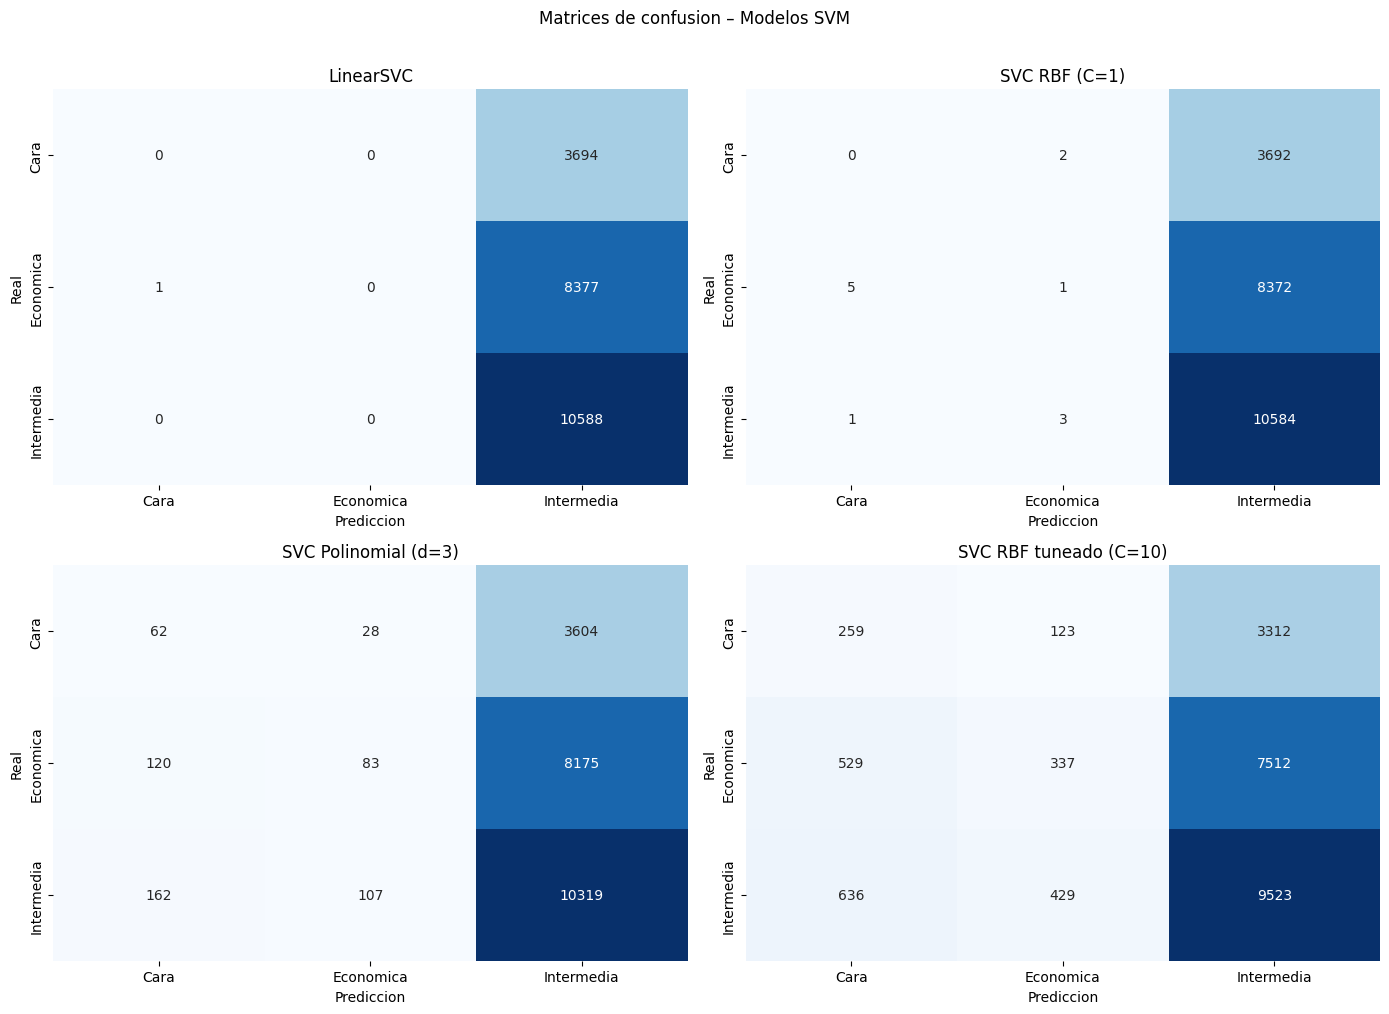

In [21]:
# Matrices de confusión de los 4 modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
clases = ['Cara', 'Economica', 'Intermedia']

for i, (nombre, datos) in enumerate(modelos_svm.items()):
    cm = confusion_matrix(y_test_cat, datos['y_pred_test'], labels=clases)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=clases, yticklabels=clases, cbar=False)
    axes[i].set_title(nombre)
    axes[i].set_xlabel('Prediccion')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrices de confusion – Modelos SVM', y=1.01)
plt.tight_layout()
plt.show()

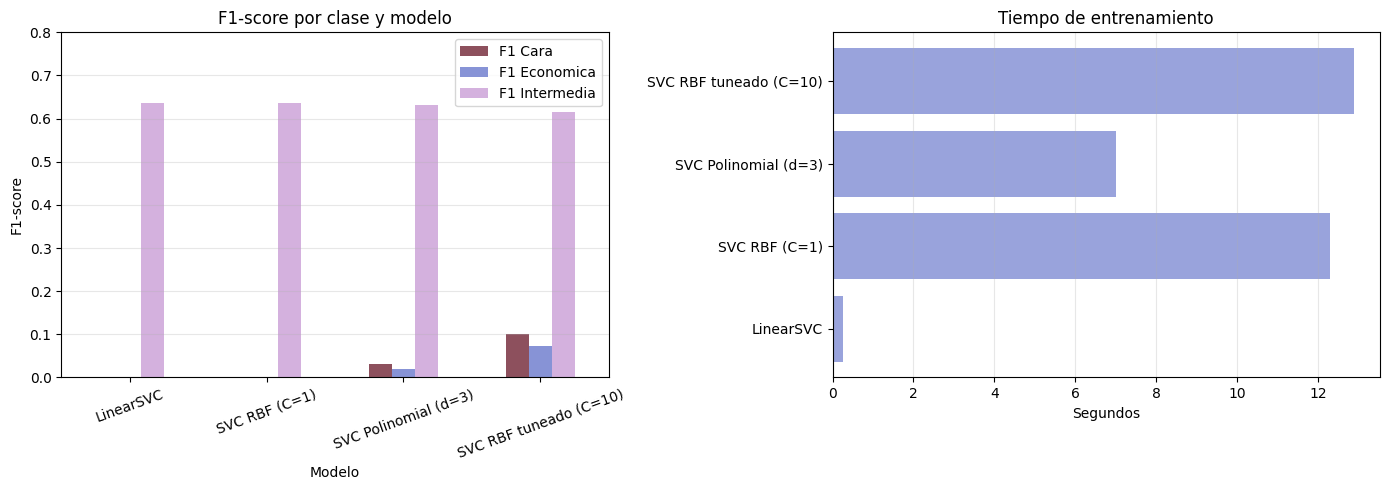

In [22]:
# Comparación visual de F1 por clase y tiempos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 por clase
df_f1 = df_svm[['Modelo', 'F1 Cara', 'F1 Economica', 'F1 Intermedia']].set_index('Modelo')
df_f1.plot(kind='bar', ax=axes[0], color=['#8d505d', '#8793d6', '#D4B1DE'])
axes[0].set_title('F1-score por clase y modelo')
axes[0].set_ylabel('F1-score')
axes[0].set_ylim(0, 0.8)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# Tiempos
axes[1].barh(df_svm['Modelo'], df_svm['Tiempo (s)'], color='#8793d6', alpha=0.85)
axes[1].set_title('Tiempo de entrenamiento')
axes[1].set_xlabel('Segundos')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Los cuatro modelos SVM muestran un rendimiento general bajo, con accuracy en test entre 0.4466 y 0.4673. La diferencia entre ellos es pequeña en términos absolutos, pero el patrón de errores varía bastante según el kernel.

**LinearSVC y SVC RBF (C=1)** son prácticamente idénticos en todas las métricas: accuracy ~0.467, F1 macro ~0.21, y F1 de Cara y Económica de 0.0000. Las matrices de confusión lo confirman de forma contundente: ambos modelos predicen Intermedia para casi el 100% de los casos. El LinearSVC clasifica correctamente una sola instancia fuera de Intermedia en todo el conjunto de prueba, y el RBF apenas un puñado. Esto no es un modelo que aprende, es un modelo que aprendió a predecir siempre la clase mayoritaria. La ventaja del LinearSVC aquí es el tiempo: 0.27 segundos frente a 12.28 del RBF, con resultados idénticos.

**SVC Polinomial (d=3)** empieza a mostrar algo diferente. F1 Cara sube a 0.0307 y F1 Económica a 0.0193, lo que se ve en la matriz: 62 Cara correctas, 83 Económicas correctas. Sigue siendo muy bajo, pero al menos el modelo ya no ignora completamente las clases minoritarias. El costo es tiempo de entrenamiento (7 segundos) sin una mejora real en accuracy, que baja ligeramente a 0.4618.

**SVC RBF tuneado (C=10)** es el que más intenta separar las tres clases: F1 Cara 0.1012, F1 Económica 0.0727, y en la matriz se ven 259 Cara correctas y 337 Económicas correctas. Sin embargo, su accuracy cae al mínimo del grupo (0.4466) porque al intentar capturar las clases minoritarias comete más errores en Intermedia (de 10,588 correctas en LinearSVC baja a 9,523). Además tarda 12.88 segundos, el más lento, con sobreajuste notable.

El error más costoso para el negocio es el falso negativo en Cara: predecir Intermedia o Económica cuando la propiedad es cara. En ese frente, el RBF tuneado es el menos malo, pero sigue fallando en 3,312 de 3,694 propiedades caras. Ningún modelo resuelve bien el problema, y la causa de fondo es el desbalance de clases combinado con variables que no tienen una frontera de decisión clara entre categorías.

### 9. Comparación del mejor SVM contra modelos de entregas anteriores

In [23]:
# El mejor SVM para esta comparación es LinearSVC (mejor acc_test, más estable, más rápido)
# Los modelos anteriores usaban variable BINARIA (Cara vs No cara), no multiclase.
# Para comparar bajo las mismas condiciones, se reentrenan todos con la variable binaria.

resultados_anteriores = []

# SVM (LinearSVC) - reentrenado con variable binaria para comparación justa
t0 = time.time()
svm_bin = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm_bin.fit(X_train_scaled, y_train_cara)
t_svm = time.time() - t0
y_pred_svm_bin = svm_bin.predict(X_test_scaled)
y_pred_svm_bin_train = svm_bin.predict(X_train_scaled)
resultados_anteriores.append({
    'Modelo'   : 'SVM (LinearSVC)',
    'y_pred'   : y_pred_svm_bin,
    'y_train'  : y_pred_svm_bin_train,
    'tiempo'   : t_svm
})

# Regresión Logística tuneada (lab7: C=1, L1, class_weight=balanced)
t0 = time.time()
lr = LogisticRegression(C=1, penalty='l1', class_weight='balanced',
                        solver='liblinear', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_cara)
t_lr = time.time() - t0
y_pred_lr = lr.predict(X_test_scaled)
resultados_anteriores.append({
    'Modelo'  : 'Reg. Logistica',
    'y_pred'  : y_pred_lr,
    'y_train' : lr.predict(X_train_scaled),
    'tiempo'  : t_lr
})

# Árbol de decisión tuneado (lab7: max_depth=15, min_samples_split=20, class_weight=balanced)
t0 = time.time()
dt = DecisionTreeClassifier(max_depth=15, min_samples_split=20,
                             class_weight='balanced', random_state=42)
dt.fit(X_train_scaled, y_train_cara)
t_dt = time.time() - t0
y_pred_dt = dt.predict(X_test_scaled)
resultados_anteriores.append({
    'Modelo'  : 'Arbol Decision',
    'y_pred'  : y_pred_dt,
    'y_train' : dt.predict(X_train_scaled),
    'tiempo'  : t_dt
})

# Random Forest tuneado (lab7: n_estimators=50, max_depth=10, class_weight=balanced)
t0 = time.time()
rf = RandomForestClassifier(n_estimators=50, max_depth=10,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_cara)
t_rf = time.time() - t0
y_pred_rf = rf.predict(X_test_scaled)
resultados_anteriores.append({
    'Modelo'  : 'Random Forest',
    'y_pred'  : y_pred_rf,
    'y_train' : rf.predict(X_train_scaled),
    'tiempo'  : t_rf
})

# KNN (lab7: k=5 por defecto, no tuneado explícitamente)
t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train_cara)
t_knn = time.time() - t0
t0_pred = time.time()
y_pred_knn = knn.predict(X_test_scaled)
t_knn_pred = time.time() - t0_pred
resultados_anteriores.append({
    'Modelo'     : 'KNN',
    'y_pred'     : y_pred_knn,
    'y_train'    : knn.predict(X_train_scaled),
    'tiempo'     : t_knn,
    'tiempo_pred': t_knn_pred
})

# Naive Bayes
t0 = time.time()
nb = GaussianNB()
nb.fit(X_train_scaled, y_train_cara)
t_nb = time.time() - t0
y_pred_nb = nb.predict(X_test_scaled)
resultados_anteriores.append({
    'Modelo'  : 'Naive Bayes',
    'y_pred'  : y_pred_nb,
    'y_train' : nb.predict(X_train_scaled),
    'tiempo'  : t_nb
})

print('Modelos reentrenados.')

Modelos reentrenados.


In [24]:
# Tabla comparativa completa
filas_comp = []
for r in resultados_anteriores:
    acc_test   = accuracy_score(y_test_cara, r['y_pred'])
    acc_train  = accuracy_score(y_train_cara, r['y_train'])
    prec       = precision_score(y_test_cara, r['y_pred'], zero_division=0)
    rec        = recall_score(y_test_cara, r['y_pred'], zero_division=0)
    f1         = f1_score(y_test_cara, r['y_pred'], zero_division=0)
    cm_r       = confusion_matrix(y_test_cara, r['y_pred'])
    tn, fp, fn, tp = cm_r.ravel()
    filas_comp.append({
        'Modelo'            : r['Modelo'],
        'Acc Train'         : round(acc_train, 4),
        'Acc Test'          : round(acc_test,  4),
        'Precision (Cara)'  : round(prec, 4),
        'Recall (Cara)'     : round(rec,  4),
        'F1 (Cara)'         : round(f1,   4),
        'FP'                : int(fp),
        'FN'                : int(fn),
        'Tiempo train (s)'  : round(r['tiempo'], 4)
    })

df_comp = pd.DataFrame(filas_comp)
print('Comparacion: SVM vs modelos anteriores (variable binaria: Cara vs No cara)')
print(df_comp.to_string(index=False))

Comparacion: SVM vs modelos anteriores (variable binaria: Cara vs No cara)
         Modelo  Acc Train  Acc Test  Precision (Cara)  Recall (Cara)  F1 (Cara)   FP   FN  Tiempo train (s)
SVM (LinearSVC)     0.7445    0.8370            0.0000         0.0000     0.0000    0 3694            0.0805
 Reg. Logistica     0.5178    0.5183            0.1650         0.4813     0.2457 9000 1916            0.1346
 Arbol Decision     0.5910    0.5905            0.1646         0.3711     0.2281 6957 2323            0.3267
  Random Forest     0.7473    0.6553            0.1659         0.2767     0.2074 5139 2672            0.3533
            KNN     0.7723    0.7633            0.1653         0.1115     0.1332 2081 3282            0.0032
    Naive Bayes     0.7346    0.8231            0.1587         0.0198     0.0351  387 3621            0.0071


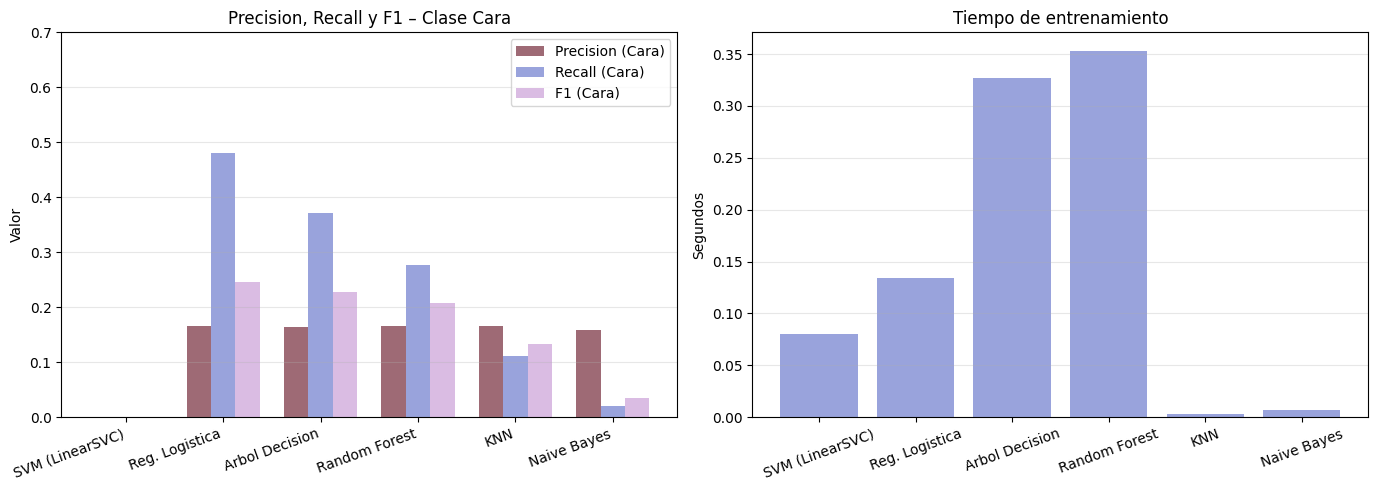

In [25]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas = ['Precision (Cara)', 'Recall (Cara)', 'F1 (Cara)']
x = np.arange(len(df_comp))
width = 0.25
colores = ['#8d505d', '#8793d6', '#D4B1DE']

for i, metrica in enumerate(metricas):
    axes[0].bar(x + i * width, df_comp[metrica], width, label=metrica, color=colores[i], alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(df_comp['Modelo'], rotation=20, ha='right')
axes[0].set_ylabel('Valor')
axes[0].set_title('Precision, Recall y F1 – Clase Cara')
axes[0].set_ylim(0, 0.7)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(df_comp['Modelo'], df_comp['Tiempo train (s)'], color='#8793d6', alpha=0.85)
axes[1].set_title('Tiempo de entrenamiento')
axes[1].set_ylabel('Segundos')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

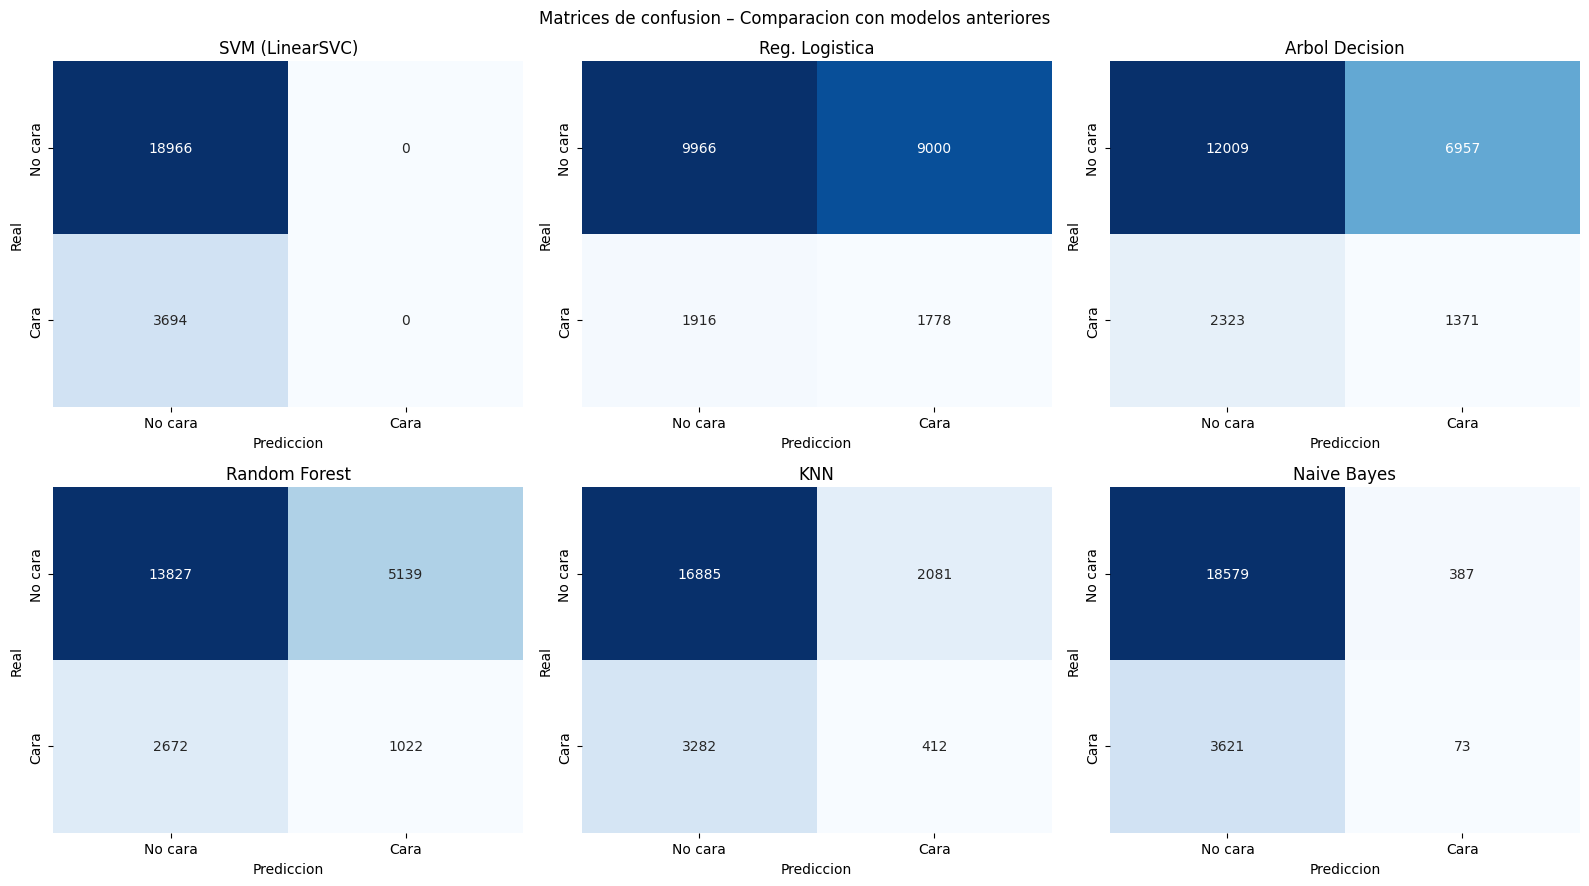

In [26]:
# Matrices de confusión de todos los modelos
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, r in enumerate(resultados_anteriores):
    cm_r = confusion_matrix(y_test_cara, r['y_pred'])
    sns.heatmap(cm_r, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No cara', 'Cara'],
                yticklabels=['No cara', 'Cara'],
                cbar=False)
    axes[i].set_title(r['Modelo'])
    axes[i].set_xlabel('Prediccion')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrices de confusion – Comparacion con modelos anteriores')
plt.tight_layout()
plt.show()

El SVM (LinearSVC) en tarea binaria tiene un resultado llamativo: accuracy de test de 0.8370, el más alto del grupo, pero con precision, recall y F1 de la clase Cara en 0.0000. La matriz lo confirma: predice No cara para los 22,660 registros sin excepción. Es el modelo con mayor accuracy pero el menos útil, porque ese 83.7% refleja únicamente la proporción natural de la clase mayoritaria en el dataset.

La Regresión Logística es el modelo que mejor detecta propiedades caras con recall de 0.4813, el más alto de todos, y F1 de 0.2457. Identifica 1,778 propiedades caras correctamente, aunque genera 9,000 falsos positivos. Para SmartStay ese trade-off es aceptable: es más costoso perder una propiedad cara que sobre-clasificar algunas intermedias como caras.

El Árbol de Decisión y Random Forest quedan en un punto intermedio. El árbol tiene recall de 0.3711 y F1 de 0.2281, Random Forest baja a recall 0.2767 y F1 de 0.2074. Ambos reducen falsos positivos respecto a la regresión logística, pero sacrifican demasiado recall para ser preferibles en este contexto.

KNN y Naive Bayes tienen los errores totales más bajos en apariencia, pero su recall en la clase Cara es de 0.1115 y 0.0198 respectivamente. Naive Bayes detecta apenas 73 propiedades caras de 3,694 posibles. Son modelos que minimizan el error total prediciendo casi siempre No cara, lo que los hace inservibles para el objetivo del negocio.

En tiempo, SVM y Naive Bayes son los más rápidos. Random Forest y Árbol son los más lentos, con KNN siendo rápido en entrenamiento pero lento en predicción a escala.

El mejor modelo es Regresión Logística: mayor recall en la clase de interés, F1 más alto, tiempo de entrenamiento bajo y comportamiento predecible. El SVM lineal no aporta nada en esta tarea binaria.

### 10. Tabla comparativa de sobreajuste – todos los modelos de clasificación

In [27]:
# Tabla de sobreajuste: train accuracy vs test accuracy para todos los modelos
filas_sf = []
for r in resultados_anteriores:
    acc_train = accuracy_score(y_train_cara, r['y_train'])
    acc_test  = accuracy_score(y_test_cara,  r['y_pred'])
    diferencia = acc_train - acc_test
    if diferencia < 0.02:
        estado = 'Sin sobreajuste'
    elif diferencia < 0.05:
        estado = 'Sobreajuste leve'
    else:
        estado = 'Sobreajuste moderado/severo'
    filas_sf.append({
        'Modelo'     : r['Modelo'],
        'Acc Train'  : round(acc_train, 4),
        'Acc Test'   : round(acc_test,  4),
        'Diferencia' : round(diferencia, 4),
        'Estado'     : estado
    })

# Agregar los 4 modelos SVM multiclase del lab8
svm_datos_sf = [
    ('LinearSVC (multiclase)',         0.5113, 0.4673),
    ('SVC RBF C=1 (multiclase)',       0.5204, 0.4671),
    ('SVC Polinomial d=3 (multiclase)',0.5348, 0.4618),
    ('SVC RBF tuneado C=10',           0.6124, 0.4469),
]
for nombre, acc_tr, acc_te in svm_datos_sf:
    dif = acc_tr - acc_te
    if dif < 0.02:
        estado = 'Sin sobreajuste'
    elif dif < 0.05:
        estado = 'Sobreajuste leve'
    else:
        estado = 'Sobreajuste moderado/severo'
    filas_sf.append({
        'Modelo'     : nombre,
        'Acc Train'  : acc_tr,
        'Acc Test'   : acc_te,
        'Diferencia' : round(dif, 4),
        'Estado'     : estado
    })

df_sf = pd.DataFrame(filas_sf).sort_values('Diferencia', ascending=False).reset_index(drop=True)
print('Tabla de sobreajuste – todos los modelos de clasificacion')
print(df_sf.to_string(index=False))

Tabla de sobreajuste – todos los modelos de clasificacion
                         Modelo  Acc Train  Acc Test  Diferencia                      Estado
           SVC RBF tuneado C=10     0.6124    0.4469      0.1655 Sobreajuste moderado/severo
                  Random Forest     0.7473    0.6553      0.0921 Sobreajuste moderado/severo
SVC Polinomial d=3 (multiclase)     0.5348    0.4618      0.0730 Sobreajuste moderado/severo
       SVC RBF C=1 (multiclase)     0.5204    0.4671      0.0533 Sobreajuste moderado/severo
         LinearSVC (multiclase)     0.5113    0.4673      0.0440            Sobreajuste leve
                            KNN     0.7723    0.7633      0.0090             Sin sobreajuste
                 Arbol Decision     0.5910    0.5905      0.0006             Sin sobreajuste
                 Reg. Logistica     0.5178    0.5183     -0.0005             Sin sobreajuste
                    Naive Bayes     0.7346    0.8231     -0.0885             Sin sobreajuste
            

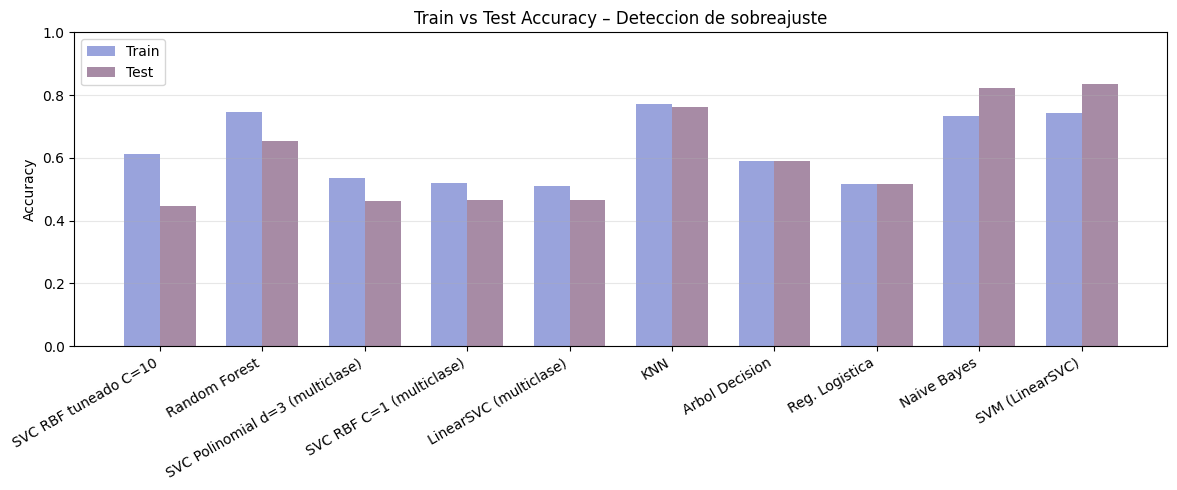

In [28]:
# Visualización del sobreajuste
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_sf))
width = 0.35

ax.bar(x - width/2, df_sf['Acc Train'], width, label='Train', color='#8793d6', alpha=0.85)
ax.bar(x + width/2, df_sf['Acc Test'],  width, label='Test',  color='#987795', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(df_sf['Modelo'], rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy – Deteccion de sobreajuste')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

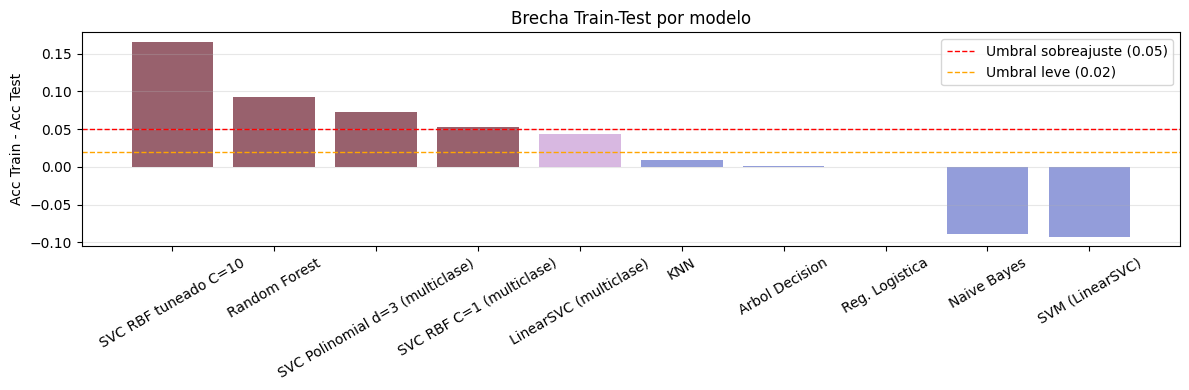

In [29]:
# Diferencia por modelo (cuánto se aleja train de test)
fig, ax = plt.subplots(figsize=(12, 4))
colores_barra = ['#8d505d' if d >= 0.05 else '#D4B1DE' if d >= 0.02 else '#8793d6'
                 for d in df_sf['Diferencia']]
ax.bar(df_sf['Modelo'], df_sf['Diferencia'], color=colores_barra, alpha=0.9)
ax.axhline(0.05, color='red',    linestyle='--', linewidth=1, label='Umbral sobreajuste (0.05)')
ax.axhline(0.02, color='orange', linestyle='--', linewidth=1, label='Umbral leve (0.02)')
ax.set_ylabel('Acc Train - Acc Test')
ax.set_title('Brecha Train-Test por modelo')
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Para determinar si un modelo está sobreajustado en clasificación se compara la accuracy en entrenamiento contra la de prueba. Una brecha positiva grande (train >> test) indica que el modelo memorizó el conjunto de entrenamiento pero no generaliza. Una brecha negativa (test > train) indica subajuste o que el modelo predice la clase mayoritaria de forma sistemática.

El modelo con sobreajuste más severo es el SVC RBF tuneado (C=10) con una brecha de 0.1655. Subir C a 10 reduce el margen del hiperplano y fuerza al modelo a clasificar correctamente casi todos los puntos de entrenamiento, memorizando el ruido de la muestra de 8,000 registros. Al evaluar en los 22,660 de test, ese ajuste no transfiere.

Random Forest tiene la segunda brecha más alta (0.0921). Aunque se limitó a max_depth=10, el ensemble de 50 árboles sigue teniendo suficiente capacidad para memorizar patrones específicos del entrenamiento que no se repiten en test.

Los modelos SVC Polinomial (0.0730) y SVC RBF C=1 multiclase (0.0533) superan el umbral de 0.05, por lo que también presentan sobreajuste moderado. El LinearSVC multiclase (0.0440) queda en zona leve, por debajo del umbral rojo pero sobre el naranja.

KNN y Árbol de Decisión tienen brechas prácticamente nulas (0.009 y 0.0006), lo que podría interpretarse como buena generalización, pero en realidad ambos tienen accuracy de train y test similares porque aprenden poco: el árbol con max_depth=15 en datos binarios llega a un límite de información disponible, y KNN simplemente vota por vecinos que en este dataset no tienen separación clara.

Naive Bayes y SVM (LinearSVC) binario muestran brechas negativas (-0.0885 y -0.0925): el test supera al train. Esto ocurre porque en entrenamiento el modelo falla en predecir la clase mayoritaria con la misma consistencia que en test, donde la distribución favorece aún más a No cara. No es generalización real, es que el modelo está subajustado y el conjunto de prueba le resulta más fácil por composición.

En resumen, los modelos más confiables para producción son los que tienen brecha pequeña y positiva con métricas de test razonables: Regresión Logística (−0.0005) y Árbol de Decisión (0.0006). El SVC RBF tuneado es el que más tiende a sobreajustarse de todo el conjunto evaluado.